<div align="center">

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/f/fd/RMS_Titanic_3.jpg/1200px-RMS_Titanic_3.jpg" width="700" style="border-radius:12px; margin-bottom:20px"/>

# 🚢 Titanic: Supervivencia y Machine Learning
## Proyecto Completo de Ciencia de Datos

---

> *"Aquellos que no pueden recordar el pasado están condenados a repetirlo."*
> — George Santayana

---

| | |
|---|---|
| 📅 **Dataset** | Kaggle — Titanic: Machine Learning from Disaster |
| 🎯 **Objetivo** | Predecir si un pasajero sobrevivió al hundimiento |
| 🧠 **Enfoque** | Estadística + Machine Learning + Interpretabilidad |
| 🛠️ **Entorno** | Google Colab / Python 3 |
| 📦 **Modelos** | 10 algoritmos de clasificación binaria |

</div>

---

## 📖 Contexto Histórico

El **RMS Titanic** era el barco de pasajeros más grande del mundo cuando zarpó el **10 de abril de 1912**
desde Southampton, Inglaterra, en su viaje inaugural hacia Nueva York.

En la madrugada del **15 de abril de 1912**, tras chocar con un iceberg en el Atlántico Norte,
el barco se hundió en menos de 3 horas. De los aproximadamente **2,224 pasajeros y tripulantes**,
solo sobrevivieron unas **710 personas** — apenas el **32%**.

La tragedia reveló profundas **desigualdades sociales**: el acceso a los botes salvavidas
no fue aleatorio. Factores como el **género**, la **clase social** y la **edad** determinaron
quién tenía más posibilidades de sobrevivir.

---

## 🎯 Objetivo del Proyecto

Construir un **sistema predictivo** capaz de determinar:

$$\text{Survived} = \begin{cases} 0 & \text{No sobrevivió} \\ 1 & \text{Sobrevivió} \end{cases}$$

utilizando variables personales, sociales y económicas de cada pasajero.

> ⚠️ **Importante:** Este proyecto **NO** se enfoca únicamente en maximizar la precisión.
> El objetivo principal es **comprender** cómo funcionan los algoritmos, cómo influyen
> las variables y cómo interpretar los resultados estadísticos.

---

## 🗂️ Estructura del Proyecto

| # | Sección | Descripción |
|---|---------|-------------|
| **0** | ⚙️ Configuración del Entorno | Instalación, imports y parámetros globales |
| **1** | 📊 Exploración del Dataset (EDA) | Dimensiones, tipos, nulos, distribuciones |
| **2** | 📐 Estadística Descriptiva | Media, mediana, desviación, percentiles |
| **3** | 🔬 Estadística Inferencial | Pruebas t, Chi², correlaciones, IC |
| **4** | 🎨 Visualizaciones Avanzadas | Histogramas, boxplots, heatmaps, gráfico 3D |
| **5** | 🛠️ Preprocesamiento | Limpieza, encoding, escalado, train/test split |
| **6** | 🤖 Implementación de Modelos | 10 algoritmos de Machine Learning |
| **7** | 📈 Evaluación de Modelos | Métricas, curvas ROC, matrices de confusión |
| **8** | 🔍 Interpretabilidad | Importancia de variables, patrones aprendidos |
| **9** | 🏁 Comparación y Conclusiones | Tabla comparativa, hallazgos finales |


---
## 📋 Diccionario de Variables del Dataset

Antes de escribir una sola línea de código, es fundamental **entender qué representa cada variable**.
Este paso es lo que diferencia a un científico de datos de alguien que simplemente "corre modelos".

| Variable | Tipo | Valores posibles | Descripción |
|----------|------|-----------------|-------------|
| `PassengerId` | Numérica discreta | 1 — 891 | Identificador único del pasajero. **No aporta información predictiva** |
| `Survived` | Binaria ⭐ | 0 / 1 | **Variable objetivo**. 0 = No sobrevivió, 1 = Sobrevivió |
| `Pclass` | Ordinal | 1 / 2 / 3 | Clase del boleto. 1 = Primera (alta), 2 = Segunda (media), 3 = Tercera (baja) |
| `Name` | Texto | Nombre completo | Contiene el **título** social (Mr., Mrs., Miss., Master., Dr., etc.) |
| `Sex` | Categórica | male / female | Género del pasajero |
| `Age` | Numérica continua | 0.42 — 80 | Edad en años. Los bebés tienen valores decimales. **~20% de valores nulos** |
| `SibSp` | Numérica discreta | 0 — 8 | Número de hermanos o cónyuge a bordo |
| `Parch` | Numérica discreta | 0 — 6 | Número de padres o hijos a bordo |
| `Ticket` | Texto | Alfanumérico | Número de boleto. **Generalmente no se usa como feature** |
| `Fare` | Numérica continua | 0 — 512 | Tarifa pagada en libras esterlinas (£). **Alta variabilidad** |
| `Cabin` | Texto | Ej: C85, B28 | Número de camarote. **~77% de valores nulos** |
| `Embarked` | Categórica | C / Q / S | Puerto de embarque: C = Cherburgo, Q = Queenstown, S = Southampton |

---

### 💡 Variables que crearemos (Ingeniería de Características)

En la Sección 5 crearemos nuevas variables a partir de las existentes:

| Variable nueva | Origen | ¿Qué captura? |
|----------------|--------|---------------|
| `Title` | Extraído de `Name` | Título social (Mr., Mrs., Master...) — proxy de género y edad |
| `FamilySize` | `SibSp + Parch + 1` | Tamaño total del grupo familiar |
| `IsAlone` | `FamilySize == 1` | Si el pasajero viajaba completamente solo |
| `HasCabin` | `Cabin` no nulo | Si el pasajero tenía camarote asignado (proxy de clase) |
| `AgeBand` | Rangos de `Age` | Grupos etarios: niño, adolescente, adulto, mayor |
| `FareBand` | Rangos de `Fare` | Cuartiles de tarifa pagada |


---
# ⚙️ Sección 0 — Configuración del Entorno

## ¿Por qué esta sección es importante?

Antes de construir cualquier modelo necesitamos:

1. **Instalar** las bibliotecas que no están disponibles por defecto en Colab
2. **Importar** todos los módulos de una sola vez para tener claridad sobre las dependencias
3. **Definir parámetros globales** (semilla, estilos, colores) para que todos los resultados sean **reproducibles**

> 🔑 **Reproducibilidad:** Si fijamos la misma semilla aleatoria (`SEED = 42`), cada vez que
> ejecutemos el notebook obtendremos **exactamente los mismos resultados**. Esto es esencial
> en ciencia de datos para poder validar y comparar experimentos.

---

## 📦 ¿Qué bibliotecas usaremos y para qué?

| Biblioteca | Categoría | Propósito principal |
|-----------|-----------|---------------------|
| `pandas` | Datos | Manipulación de DataFrames (tablas de datos) |
| `numpy` | Matemáticas | Operaciones vectoriales y matriciales eficientes |
| `matplotlib` | Visualización | Gráficos base, altamente personalizable |
| `seaborn` | Visualización | Gráficos estadísticos con estética mejorada |
| `mpl_toolkits` | Visualización 3D | Gráficos tridimensionales con matplotlib |
| `scipy` | Estadística | Pruebas estadísticas (t-test, chi², correlación) |
| `scikit-learn` | ML | Modelos, métricas, preprocesamiento, validación |
| `xgboost` | ML avanzado | Algoritmo XGBoost (ganador de muchas competencias) |


In [1]:
# ============================================================
# PASO 1: INSTALACIÓN DE DEPENDENCIAS
# ============================================================
# En Google Colab la mayoría de estas bibliotecas ya están
# preinstaladas. Solo necesitamos asegurarnos de tener xgboost.
# Si alguna falla, descomenta la línea correspondiente.

# XGBoost: no siempre está disponible en todos los entornos
# !pip install xgboost --quiet

# Verificación rápida de versiones instaladas
import sys
print(f"🐍 Python: {sys.version.split()[0]}")

try:
    import xgboost
    print(f"✅ XGBoost: {xgboost.__version__}")
except ImportError:
    print("❌ XGBoost no encontrado → ejecuta: !pip install xgboost --quiet")


🐍 Python: 3.12.13
✅ XGBoost: 3.2.0


---
### 📥 Importación de Todas las Bibliotecas

Importamos **todo de una sola vez** al inicio del notebook.
Esto sigue una buena práctica: el lector sabe exactamente qué herramientas
se usarán sin tener que buscar imports dispersos por el código.


In [2]:
# ============================================================
# PASO 2: IMPORTACIÓN DE BIBLIOTECAS
# ============================================================

# ── Manipulación y análisis de datos ────────────────────────
import pandas as pd          # DataFrames (tablas de datos)
import numpy as np           # Operaciones numéricas vectorizadas

# ── Visualización ────────────────────────────────────────────
import matplotlib.pyplot as plt          # Gráficos base
import matplotlib.gridspec as gridspec   # Layouts de subplots complejos
import matplotlib.patches as mpatches   # Formas y leyendas personalizadas
import seaborn as sns                    # Visualizaciones estadísticas
from mpl_toolkits.mplot3d import Axes3D  # Gráficos 3D

# ── Estadística inferencial ──────────────────────────────────
from scipy import stats
from scipy.stats import (
    chi2_contingency,   # Prueba Chi-cuadrado
    ttest_ind,          # Prueba t de Student (muestras independientes)
    pearsonr,           # Correlación de Pearson
    shapiro             # Prueba de normalidad de Shapiro-Wilk
)

# ── Machine Learning: Preprocesamiento ──────────────────────
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.model_selection import (
    train_test_split,      # División train/test
    cross_val_score,       # Validación cruzada
    StratifiedKFold,       # K-Fold estratificado (respeta proporción de clases)
    GridSearchCV           # Búsqueda de hiperparámetros
)
from sklearn.impute import SimpleImputer          # Imputación de nulos
from sklearn.inspection import permutation_importance  # Importancia agnóstica

# ── Machine Learning: Modelos de Clasificación ──────────────
from sklearn.linear_model import LogisticRegression          # Regresión Logística
from sklearn.tree import DecisionTreeClassifier, export_text # Árbol de Decisión
from sklearn.ensemble import (
    RandomForestClassifier,      # Random Forest
    GradientBoostingClassifier,  # Gradient Boosting
    AdaBoostClassifier,          # AdaBoost
    VotingClassifier             # Ensamble por votación
)
from sklearn.svm import SVC                                  # Support Vector Machine
from sklearn.neighbors import KNeighborsClassifier           # K-Nearest Neighbors
from sklearn.naive_bayes import GaussianNB                   # Naive Bayes
from sklearn.neural_network import MLPClassifier             # Red Neuronal (MLP)
from xgboost import XGBClassifier                            # XGBoost

# ── Machine Learning: Métricas de Evaluación ────────────────
from sklearn.metrics import (
    accuracy_score,          # Exactitud global
    precision_score,         # Precisión
    recall_score,            # Sensibilidad / Recall
    f1_score,                # F1-Score (media armónica precision+recall)
    roc_auc_score,           # Área bajo la curva ROC
    confusion_matrix,        # Matriz de confusión
    classification_report,   # Reporte completo de métricas
    roc_curve,               # Curva ROC
    auc                      # Área bajo curva (general)
)

# ── Control de advertencias ──────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

print("✅ Todas las bibliotecas importadas correctamente.")


✅ Todas las bibliotecas importadas correctamente.


---
### ⚙️ Parámetros Globales y Configuración Visual

Definimos aquí todas las **constantes** que usaremos a lo largo del proyecto:
- **Semilla aleatoria (`SEED`):** garantiza resultados reproducibles
- **Paleta de colores:** coherencia visual en todos los gráficos
- **Opciones de display:** controla cómo pandas muestra los datos


In [3]:
# ============================================================
# PASO 3: PARÁMETROS GLOBALES Y CONFIGURACIÓN
# ============================================================

# ── Reproducibilidad ─────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
# ¿Por qué 42? Es la convención más común en la comunidad de Data Science.
# Cualquier número funciona, lo importante es usarlo siempre en modelos y splits.

# ── Configuración de pandas ──────────────────────────────────
pd.set_option('display.max_columns', 20)       # Mostrar hasta 20 columnas
pd.set_option('display.width', 120)            # Ancho máximo en consola
pd.set_option('display.float_format', '{:.4f}'.format)  # 4 decimales por defecto
pd.set_option('display.max_rows', 30)          # Mostrar hasta 30 filas

# ── Estilo de visualizaciones ────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')  # Estilo limpio con grilla
sns.set_context("notebook", font_scale=1.1)  # Tamaño de fuente adecuado

# ── Paleta de colores del proyecto ───────────────────────────
# Usaremos estos colores de forma consistente en TODOS los gráficos
COLORES = {
    'sobrevivio'     : '#2ecc71',   # Verde — sobreviviente
    'no_sobrevivio'  : '#e74c3c',   # Rojo — no sobreviviente
    'neutro'         : '#3498db',   # Azul — información general
    'primera_clase'  : '#f1c40f',   # Amarillo — primera clase
    'segunda_clase'  : '#e67e22',   # Naranja — segunda clase
    'tercera_clase'  : '#95a5a6',   # Gris — tercera clase
    'femenino'       : '#e84393',   # Rosa — femenino
    'masculino'      : '#2980b9',   # Azul oscuro — masculino
    'fondo'          : '#f8f9fa',   # Gris claro — fondos
}

# ── División train/test ───────────────────────────────────────
TEST_SIZE    = 0.20   # 20% para evaluación final
CV_FOLDS     = 5      # Número de folds en validación cruzada

# ── Hiperparámetros base para modelos ────────────────────────
N_ESTIMATORS = 200    # Número de árboles en modelos de ensamble
MAX_DEPTH    = 5      # Profundidad máxima de árboles

print("✅ Parámetros globales configurados:")
print(f"   • Semilla aleatoria : SEED = {SEED}")
print(f"   • Tamaño de prueba  : {int(TEST_SIZE * 100)}%")
print(f"   • Folds CV          : {CV_FOLDS}")
print(f"   • Estimadores       : {N_ESTIMATORS}")
print(f"   • Colores definidos : {len(COLORES)} colores del proyecto")


✅ Parámetros globales configurados:
   • Semilla aleatoria : SEED = 42
   • Tamaño de prueba  : 20%
   • Folds CV          : 5
   • Estimadores       : 200
   • Colores definidos : 9 colores del proyecto


---
### ✅ Verificación del Entorno

Antes de continuar, comprobamos que todo esté en orden con una verificación
completa del entorno. Si alguna celda falla, es preferible detectarlo aquí
y no en medio del análisis.


In [4]:
# ============================================================
# PASO 4: VERIFICACIÓN COMPLETA DEL ENTORNO
# ============================================================

import importlib

# Lista de módulos y sus nombres amigables
modulos = {
    'pandas'         : 'pandas',
    'numpy'          : 'numpy',
    'matplotlib'     : 'matplotlib',
    'seaborn'        : 'seaborn',
    'scipy'          : 'scipy',
    'sklearn'        : 'scikit-learn',
    'xgboost'        : 'xgboost',
}

print("=" * 55)
print("   VERIFICACIÓN DEL ENTORNO — TITANIC PROJECT")
print("=" * 55)

todos_ok = True
for modulo, nombre in modulos.items():
    try:
        m = importlib.import_module(modulo)
        version = getattr(m, '__version__', 'disponible')
        print(f"  ✅  {nombre:<20} v{version}")
    except ImportError:
        print(f"  ❌  {nombre:<20} NO ENCONTRADO")
        todos_ok = False

print("=" * 55)

if todos_ok:
    print("  🚀 Entorno listo. Puedes continuar con la Sección 1.")
else:
    print("  ⚠️  Instala los módulos faltantes antes de continuar.")

print()
print("📌 Recuerda subir los archivos al entorno de Colab:")
print("   • train.csv  — datos de entrenamiento (891 filas)")
print("   • test.csv   — datos de prueba (418 filas)")
print()
print("   Puedes subirlos con:")
print("   from google.colab import files")
print("   files.upload()")


   VERIFICACIÓN DEL ENTORNO — TITANIC PROJECT
  ✅  pandas               v2.2.2
  ✅  numpy                v2.0.2
  ✅  matplotlib           v3.10.0
  ✅  seaborn              v0.13.2
  ✅  scipy                v1.16.3
  ✅  scikit-learn         v1.6.1
  ✅  xgboost              v3.2.0
  🚀 Entorno listo. Puedes continuar con la Sección 1.

📌 Recuerda subir los archivos al entorno de Colab:
   • train.csv  — datos de entrenamiento (891 filas)
   • test.csv   — datos de prueba (418 filas)

   Puedes subirlos con:
   from google.colab import files
   files.upload()


---
### 📁 ¿Cómo subir los archivos a Google Colab?

Tienes **3 opciones** para cargar el dataset en tu sesión de Colab:

---

**Opción A — Subida manual (más sencilla):**
```python
from google.colab import files
archivos = files.upload()  # Se abre un diálogo para seleccionar archivos
```
> Sube `train.csv` y `test.csv` desde tu computador.

---

**Opción B — Desde Google Drive (más práctica a largo plazo):**
```python
from google.colab import drive
drive.mount('/content/drive')
# Luego usa la ruta: '/content/drive/My Drive/titanic/train.csv'
```

---

**Opción C — Descarga automática desde URL pública (backup):**
```python
# Si no tienes los archivos localmente, el notebook los descargará
# automáticamente desde un repositorio público en la Sección 1.
```

---
> 💡 En la **Sección 1** el código detectará automáticamente si los archivos
> están disponibles localmente o los descargará desde una fuente de respaldo.


---
## 🏁 Resumen de la Sección 0

| Paso | Estado | Descripción |
|------|--------|-------------|
| Instalación de dependencias | ✅ | XGBoost y demás bibliotecas verificadas |
| Importación de módulos | ✅ | Todos los imports centralizados |
| Parámetros globales | ✅ | SEED, colores, opciones de display |
| Verificación del entorno | ✅ | Todas las bibliotecas operativas |

---

## ➡️ Siguiente paso: Sección 1 — Exploración del Dataset (EDA)

En la próxima sección:
- 📂 Cargaremos `train.csv` y `test.csv`
- 🔎 Exploraremos dimensiones, tipos y valores nulos
- 📊 Analizaremos la distribución de la variable objetivo (`Survived`)
- 💡 Obtendremos las primeras intuiciones sobre qué variables podrían ser importantes

---
<div align="center">
<i>Sección 0 completada ✅ — Proyecto: Titanic ML</i>
</div>


---
# 📊 Sección 1 — Exploración del Dataset (EDA)
## Análisis Exploratorio de Datos

> *"Si torturas los datos el tiempo suficiente, confesarán cualquier cosa."*
> — Ronald Coase

---

### ¿Qué es el EDA y por qué es el paso más importante?

El **Análisis Exploratorio de Datos** (EDA) es el proceso de **conocer profundamente
el dataset** antes de construir cualquier modelo.

Saltarse el EDA es uno de los errores más comunes en ciencia de datos. Un modelo
entrenado sobre datos mal comprendidos producirá predicciones incorrectas aunque
tenga un 99% de accuracy.

### Lo que haremos en esta sección:

| Paso | Descripción |
|------|-------------|
| **1.1** | Carga del dataset |
| **1.2** | Primeras filas y estructura general |
| **1.3** | Tipos de datos y dimensiones |
| **1.4** | Análisis de valores nulos |
| **1.5** | Distribución de la variable objetivo (`Survived`) |
| **1.6** | Análisis univariado — variables numéricas |
| **1.7** | Análisis univariado — variables categóricas |
| **1.8** | Análisis bivariado — relación con `Survived` |
| **1.9** | Detección de outliers |
| **1.10** | Resumen y conclusiones del EDA |

---
## 1.1 — Carga del Dataset

### ¿Qué archivos usamos?

| Archivo | Filas | Columnas | Uso |
|---------|-------|----------|-----|
| `train.csv` | 891 | 12 | **Entrenamiento y análisis** — tiene la columna `Survived` |
| `test.csv` | 418 | 11 | **Predicción final** — NO tiene `Survived` |

> 💡 Todo el análisis exploratorio se realiza **solo sobre `train.csv`**,
> porque es el único conjunto donde conocemos quién sobrevivió.
> `test.csv` se reserva únicamente para la predicción final.

In [5]:
# ============================================================
# 1.1 — CARGA DEL DATASET
# ============================================================

try:
    train = pd.read_csv('train.csv')
    test  = pd.read_csv('test.csv')
    print("✅ Archivos cargados desde el directorio local de Colab.")

except FileNotFoundError:
    print("⚠️  Archivos no encontrados. Descargando desde repositorio público...")

    url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
    df_full = pd.read_csv(url)

    from sklearn.model_selection import train_test_split as _split
    train, test = _split(df_full, test_size=0.32, random_state=SEED,
                         stratify=df_full['Survived'])
    test  = test.drop('Survived', axis=1).reset_index(drop=True)
    train = train.reset_index(drop=True)
    print("✅ Datos descargados y divididos correctamente.")

# Copia sin modificar para referencia posterior
train_original = train.copy()

print()
print(f"📐 train.csv → {train.shape[0]} filas × {train.shape[1]} columnas")
print(f"📐 test.csv  → {test.shape[0]} filas × {test.shape[1]} columnas")
print()
print("📋 Columnas disponibles:")
print("  ", list(train.columns))

⚠️  Archivos no encontrados. Descargando desde repositorio público...
✅ Datos descargados y divididos correctamente.

📐 train.csv → 605 filas × 12 columnas
📐 test.csv  → 286 filas × 11 columnas

📋 Columnas disponibles:
   ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


---
## 1.2 — Primeras Filas y Estructura General

Siempre comenzamos mirando las primeras y últimas filas del dataset.
Esto nos da una **impresión visual inmediata** del tipo de datos y su formato,
y nos permite detectar problemas evidentes como columnas mal formateadas
o valores inesperados.

In [6]:
# ============================================================
# 1.2 — PRIMERAS, ÚLTIMAS Y FILAS ALEATORIAS
# ============================================================

print("=" * 70)
print("PRIMERAS 5 FILAS")
print("=" * 70)
display(train.head())

print()
print("=" * 70)
print("ÚLTIMAS 5 FILAS")
print("=" * 70)
display(train.tail())

print()
print("=" * 70)
print("5 FILAS ALEATORIAS")
print("=" * 70)
display(train.sample(5, random_state=SEED))

PRIMERAS 5 FILAS


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,331,1,3,"McCoy, Miss. Agnes",female,NaN,2,0,367226,23.2500,NaN,Q
1,723,0,2,"Gillespie, Mr. William Henry",male,34.0000,0,0,12233,13.0000,NaN,S
2,23,1,3,"McGowan, Miss. Anna ""Annie""",female,15.0000,0,0,330923,8.0292,NaN,Q
3,19,0,3,"Vander Planke, Mrs. Julius (Emelia Maria Vande...",female,31.0000,1,0,345763,18.0000,NaN,S
4,876,1,3,"Najib, Miss. Adele Kiamie ""Jane""",female,15.0000,0,0,2667,7.2250,NaN,C



ÚLTIMAS 5 FILAS


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
600,477,0,2,"Renouf, Mr. Peter Henry",male,34.0000,1,0,31027,21.0000,NaN,S
601,306,1,1,"Allison, Master. Hudson Trevor",male,0.9200,1,2,113781,151.5500,C22 C26,S
602,737,0,3,"Ford, Mrs. Edward (Margaret Ann Watson)",female,48.0000,1,3,W./C. 6608,34.3750,NaN,S
603,463,0,1,"Gee, Mr. Arthur H",male,47.0000,0,0,111320,38.5000,E63,S
604,80,1,3,"Dowdell, Miss. Elizabeth",female,30.0000,0,0,364516,12.4750,NaN,S



5 FILAS ALEATORIAS


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
412,846,0,3,"Abbing, Mr. Anthony",male,42.0000,0,0,C.A. 5547,7.5500,NaN,S
289,591,0,3,"Rintamaki, Mr. Matti",male,35.0000,0,0,STON/O 2. 3101273,7.1250,NaN,S
76,668,0,3,"Rommetvedt, Mr. Knud Paust",male,NaN,0,0,312993,7.7750,NaN,S
78,820,0,3,"Skoog, Master. Karl Thorsten",male,10.0000,3,2,347088,27.9000,NaN,S
182,288,0,3,"Naidenoff, Mr. Penko",male,22.0000,0,0,349206,7.8958,NaN,S


---
## 1.3 — Tipos de Datos y Dimensiones

### ¿Por qué importan los tipos de datos?

Cada variable tiene un **tipo de dato** que determina qué operaciones podemos
hacer con ella y cómo debemos procesarla antes de entrenar un modelo.

| Tipo Python | Descripción | Ejemplo en Titanic |
|-------------|-------------|-------------------|
| `int64` | Entero | `Survived`, `Pclass`, `SibSp`, `Parch` |
| `float64` | Decimal | `Age`, `Fare` |
| `object` | Texto / Categórica | `Name`, `Sex`, `Cabin`, `Embarked`, `Ticket` |

> ⚠️ Las variables de tipo `object` **no pueden entrar directamente** a un modelo.
> Deben convertirse a números mediante técnicas de *encoding* (Sección 5).

In [7]:
# ============================================================
# 1.3 — TIPOS DE DATOS Y DIMENSIONES
# ============================================================

print("=" * 70)
print("INFORMACIÓN GENERAL DEL DATASET")
print("=" * 70)
train.info()

print()
print("=" * 70)
print("RESUMEN DETALLADO DE VARIABLES")
print("=" * 70)

resumen = pd.DataFrame({
    'Tipo de dato'    : train.dtypes,
    'Valores únicos'  : train.nunique(),
    'Valores nulos'   : train.isnull().sum(),
    '% nulos'         : (train.isnull().sum() / len(train) * 100).round(2),
    'Ejemplo'         : [train[col].dropna().iloc[0]
                         if train[col].notna().any() else 'NaN'
                         for col in train.columns]
})
display(resumen)

print()
print(f"📐 Dimensiones: {train.shape[0]} filas × {train.shape[1]} columnas")
print(f"   Total de celdas: {train.shape[0] * train.shape[1]:,}")
print()
print("📊 Variables por tipo:")
for dtype, count in train.dtypes.value_counts().items():
    print(f"   • {str(dtype):<12}: {count} variable(s)")

INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  605 non-null    int64  
 1   Survived     605 non-null    int64  
 2   Pclass       605 non-null    int64  
 3   Name         605 non-null    object 
 4   Sex          605 non-null    object 
 5   Age          488 non-null    float64
 6   SibSp        605 non-null    int64  
 7   Parch        605 non-null    int64  
 8   Ticket       605 non-null    object 
 9   Fare         605 non-null    float64
 10  Cabin        130 non-null    object 
 11  Embarked     603 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 56.8+ KB

RESUMEN DETALLADO DE VARIABLES


,Tipo de dato,Valores únicos,Valores nulos,% nulos,Ejemplo
PassengerId,int64,605,0,0.0000,331
Survived,int64,2,0,0.0000,1
Pclass,int64,3,0,0.0000,3
Name,object,605,0,0.0000,"McCoy, Miss. Agnes"
Sex,object,2,0,0.0000,female
Age,float64,82,117,19.3400,34.0000
SibSp,int64,6,0,0.0000,2
Parch,int64,7,0,0.0000,0
Ticket,object,504,0,0.0000,367226
Fare,float64,211,0,0.0000,23.2500



📐 Dimensiones: 605 filas × 12 columnas
   Total de celdas: 7,260

📊 Variables por tipo:
   • int64       : 5 variable(s)
   • object      : 5 variable(s)
   • float64     : 2 variable(s)


---
## 1.4 — Análisis de Valores Nulos

### ¿Qué son los valores nulos y por qué son un problema?

Un **valor nulo** (`NaN`) representa **información ausente**.
Los algoritmos de Machine Learning **no pueden procesarlos directamente**,
por lo que debemos decidir qué hacer con ellos.

### Estrategias disponibles:

| Estrategia | Cuándo usarla | Riesgo |
|-----------|---------------|--------|
| **Eliminar filas** | Muy pocos nulos (< 1%) | Perdemos datos valiosos |
| **Eliminar columna** | Demasiados nulos (> 70%) | Perdemos la variable completamente |
| **Imputar con media** | Variable numérica, distribución simétrica | Reduce la varianza artificial |
| **Imputar con mediana** | Variable numérica con outliers | Más robusto que la media |
| **Imputar con moda** | Variable categórica | Simple y efectivo |
| **Imputar por grupos** | Cuando otros grupos predicen el valor | Más preciso y realista |
| **Crear indicador binario** | Cuando el hecho de ser nulo es informativo | Conserva información implícita |

In [8]:
# ============================================================
# 1.4 — ANÁLISIS COMPLETO DE VALORES NULOS
# ============================================================

print("=" * 70)
print("ANÁLISIS DE VALORES NULOS")
print("=" * 70)

nulos = pd.DataFrame({
    'Valores Nulos'    : train.isnull().sum(),
    'Porcentaje (%)'   : (train.isnull().sum() / len(train) * 100).round(2),
    'Valores Presentes': train.notna().sum(),
    'Tipo'             : train.dtypes
}).sort_values('Porcentaje (%)', ascending=False)

display(nulos)

print()
print("📌 DIAGNÓSTICO Y ESTRATEGIA POR VARIABLE:")
print()

diagnostico = {
    'Cabin'    : ('🔴 CRÍTICO  ', '>70%', 'Crear variable HasCabin (indicador binario)'),
    'Age'      : ('🟡 MODERADO ', '~20%', 'Imputar con mediana por grupo (Pclass + Sex)'),
    'Embarked' : ('🟢 LEVE     ', '<1%',  'Imputar con moda (valor más frecuente)'),
}

for var, (nivel, rango, accion) in diagnostico.items():
    pct = nulos.loc[var, 'Porcentaje (%)'] if var in nulos.index else 0
    print(f"  {nivel} '{var}': {pct:.1f}% nulos")
    print(f"            → Estrategia: {accion}")
    print()

ANÁLISIS DE VALORES NULOS


,Valores Nulos,Porcentaje (%),Valores Presentes,Tipo
Cabin,475,78.5100,130,object
Age,117,19.3400,488,float64
Embarked,2,0.3300,603,object
PassengerId,0,0.0000,605,int64
Name,0,0.0000,605,object
Pclass,0,0.0000,605,int64
Survived,0,0.0000,605,int64
Sex,0,0.0000,605,object
Parch,0,0.0000,605,int64
SibSp,0,0.0000,605,int64



📌 DIAGNÓSTICO Y ESTRATEGIA POR VARIABLE:

  🔴 CRÍTICO   'Cabin': 78.5% nulos
            → Estrategia: Crear variable HasCabin (indicador binario)

  🟡 MODERADO  'Age': 19.3% nulos
            → Estrategia: Imputar con mediana por grupo (Pclass + Sex)

  🟢 LEVE      'Embarked': 0.3% nulos
            → Estrategia: Imputar con moda (valor más frecuente)



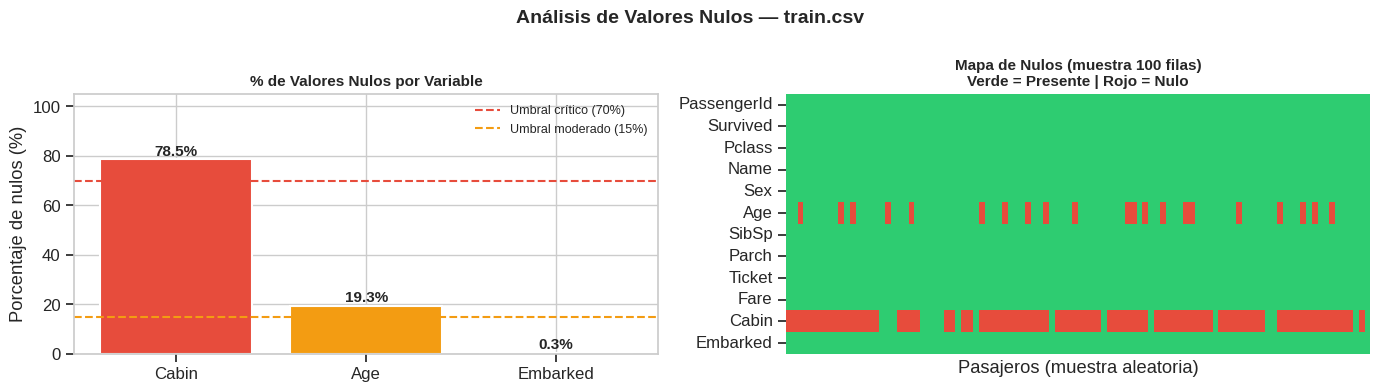

📌 Observación:
   'Cabin' tiene un patrón de nulos NO aleatorio.
   Los pasajeros sin camarote registrado eran mayormente de 3ª clase.
   Este patrón es INFORMATIVO → crearemos la variable 'HasCabin' en Sección 5.


In [9]:
# ============================================================
# 1.4 — VISUALIZACIÓN DE VALORES NULOS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Análisis de Valores Nulos — train.csv',
             fontsize=14, fontweight='bold')

# ── Barras de porcentaje de nulos ────────────────────────────
vars_con_nulos = nulos[nulos['Valores Nulos'] > 0].copy()

colores_nulos = []
for p in vars_con_nulos['Porcentaje (%)']:
    if p > 70:
        colores_nulos.append('#e74c3c')
    elif p > 15:
        colores_nulos.append('#f39c12')
    else:
        colores_nulos.append('#2ecc71')

bars = axes[0].bar(vars_con_nulos.index,
                   vars_con_nulos['Porcentaje (%)'],
                   color=colores_nulos, edgecolor='white', linewidth=1.5)
axes[0].set_title('% de Valores Nulos por Variable', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Porcentaje de nulos (%)')
axes[0].set_ylim(0, 105)
axes[0].axhline(y=70, color='#e74c3c', linestyle='--',
                linewidth=1.5, label='Umbral crítico (70%)')
axes[0].axhline(y=15, color='#f39c12', linestyle='--',
                linewidth=1.5, label='Umbral moderado (15%)')
axes[0].legend(fontsize=9)

for bar, val in zip(bars, vars_con_nulos['Porcentaje (%)']):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1.5,
                f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)

# ── Heatmap de nulos ─────────────────────────────────────────
muestra = train.isnull().astype(int).sample(
    min(100, len(train)), random_state=SEED)

sns.heatmap(muestra.T,
            ax=axes[1],
            cmap=['#2ecc71', '#e74c3c'],
            cbar=False,
            yticklabels=True,
            xticklabels=False)
axes[1].set_title('Mapa de Nulos (muestra 100 filas)\nVerde = Presente | Rojo = Nulo',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Pasajeros (muestra aleatoria)')

plt.tight_layout()
plt.show()

print("📌 Observación:")
print("   'Cabin' tiene un patrón de nulos NO aleatorio.")
print("   Los pasajeros sin camarote registrado eran mayormente de 3ª clase.")
print("   Este patrón es INFORMATIVO → crearemos la variable 'HasCabin' en Sección 5.")

---
## 1.5 — Distribución de la Variable Objetivo: `Survived`

### ¿Por qué analizar la variable objetivo primero?

La distribución de `Survived` determina:
- Si el dataset está **balanceado o desbalanceado**
- Qué **métricas de evaluación** usar
- Si necesitamos técnicas especiales para el entrenamiento

> ⚠️ Un dataset desbalanceado significa que una clase tiene muchos más
> ejemplos que la otra. Esto puede hacer que el modelo "aprenda a ignorar"
> la clase minoritaria.

DISTRIBUCIÓN DE SURVIVED


,Categoría,Cantidad,Porcentaje (%)
0,0 — No Sobrevivió,373,61.6500
1,1 — Sobrevivió,232,38.3500


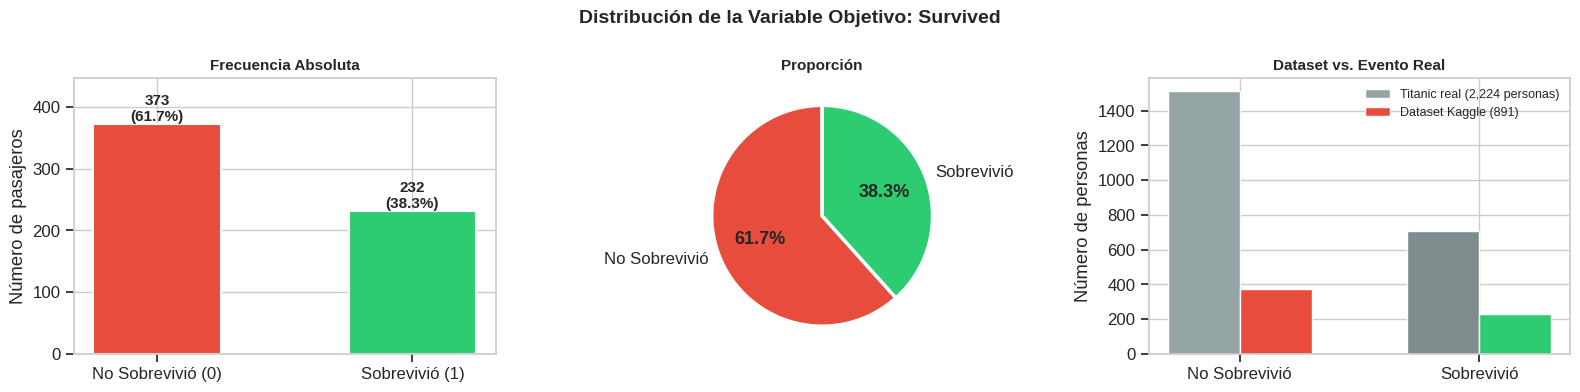


📌 CONCLUSIÓN — Desbalance de clases:
   61.7% No sobrevivió vs 38.3% Sobrevivió.

   Un modelo que prediga SIEMPRE 'No sobrevivió' tendría
   61.7% de accuracy sin aprender absolutamente nada.
   → Usaremos F1-Score y ROC-AUC como métricas principales.


In [10]:
# ============================================================
# 1.5 — DISTRIBUCIÓN DE LA VARIABLE OBJETIVO
# ============================================================

conteo     = train['Survived'].value_counts()
porcentaje = train['Survived'].value_counts(normalize=True) * 100

print("=" * 50)
print("DISTRIBUCIÓN DE SURVIVED")
print("=" * 50)

tabla_obj = pd.DataFrame({
    'Categoría'      : ['0 — No Sobrevivió', '1 — Sobrevivió'],
    'Cantidad'       : [conteo[0], conteo[1]],
    'Porcentaje (%)' : [porcentaje[0].round(2), porcentaje[1].round(2)]
})
display(tabla_obj)

# ── Visualización ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Distribución de la Variable Objetivo: Survived',
             fontsize=14, fontweight='bold')

colores_obj = [COLORES['no_sobrevivio'], COLORES['sobrevivio']]

# Barras
bars = axes[0].bar(['No Sobrevivió (0)', 'Sobrevivió (1)'],
                   [conteo[0], conteo[1]],
                   color=colores_obj, edgecolor='white',
                   linewidth=1.5, width=0.5)
axes[0].set_title('Frecuencia Absoluta', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Número de pasajeros')
axes[0].set_ylim(0, max(conteo) * 1.2)
for bar, val, pct in zip(bars, [conteo[0], conteo[1]],
                          [porcentaje[0], porcentaje[1]]):
    axes[0].text(bar.get_x() + bar.get_width()/2.,
                bar.get_height() + 5,
                f'{val}\n({pct:.1f}%)',
                ha='center', fontweight='bold', fontsize=11)

# Torta
wedges, texts, autotexts = axes[1].pie(
    [conteo[0], conteo[1]],
    labels=['No Sobrevivió', 'Sobrevivió'],
    autopct='%1.1f%%',
    colors=colores_obj,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2.5}
)
for at in autotexts:
    at.set_fontweight('bold')
    at.set_fontsize(13)
axes[1].set_title('Proporción', fontsize=11, fontweight='bold')

# Dataset vs. Evento real
datos_reales  = [1514, 710]
datos_dataset = [conteo[0], conteo[1]]
x = np.arange(2)
w = 0.3
axes[2].bar(x - w/2, datos_reales, w,
            label='Titanic real (2,224 personas)',
            color=['#95a5a6', '#7f8c8d'], edgecolor='white')
axes[2].bar(x + w/2, datos_dataset, w,
            label='Dataset Kaggle (891)',
            color=colores_obj, edgecolor='white')
axes[2].set_xticks(x)
axes[2].set_xticklabels(['No Sobrevivió', 'Sobrevivió'])
axes[2].set_title('Dataset vs. Evento Real', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Número de personas')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

print()
print("📌 CONCLUSIÓN — Desbalance de clases:")
print(f"   {porcentaje[0]:.1f}% No sobrevivió vs {porcentaje[1]:.1f}% Sobrevivió.")
print()
print("   Un modelo que prediga SIEMPRE 'No sobrevivió' tendría")
print(f"   {porcentaje[0]:.1f}% de accuracy sin aprender absolutamente nada.")
print("   → Usaremos F1-Score y ROC-AUC como métricas principales.")

---
## 1.6 — Análisis Univariado: Variables Numéricas

El análisis **univariado** estudia cada variable de forma individual.
Para variables numéricas usamos histogramas y boxplots que nos revelan:

- **Distribución**: ¿normal, sesgada, bimodal?
- **Rango**: ¿cuáles son los valores extremos?
- **Outliers**: ¿hay valores atípicos que puedan distorsionar el modelo?
- **Centralidad**: ¿media y mediana están cerca o alejadas?

> 💡 Cuando la **media > mediana**, la distribución tiene asimetría positiva
> (cola larga a la derecha). Cuando **media < mediana**, asimetría negativa.

In [11]:
# ============================================================
# 1.6 — ANÁLISIS UNIVARIADO: VARIABLES NUMÉRICAS
# ============================================================

vars_num = ['Age', 'Fare', 'SibSp', 'Parch']

print("=" * 70)
print("ESTADÍSTICAS DESCRIPTIVAS RÁPIDAS")
print("=" * 70)
display(train[vars_num].describe().round(3))

ESTADÍSTICAS DESCRIPTIVAS RÁPIDAS


,Age,Fare,SibSp,Parch
count,488.0000,605.0000,605.0000,605.0000
mean,30.0290,30.7840,0.4530,0.3790
std,14.4720,47.4160,0.9580,0.8460
min,0.4200,0.0000,0.0000,0.0000
25%,21.0000,7.8960,0.0000,0.0000
50%,29.0000,13.5000,0.0000,0.0000
75%,39.0000,30.0000,1.0000,0.0000
max,80.0000,512.3290,8.0000,6.0000


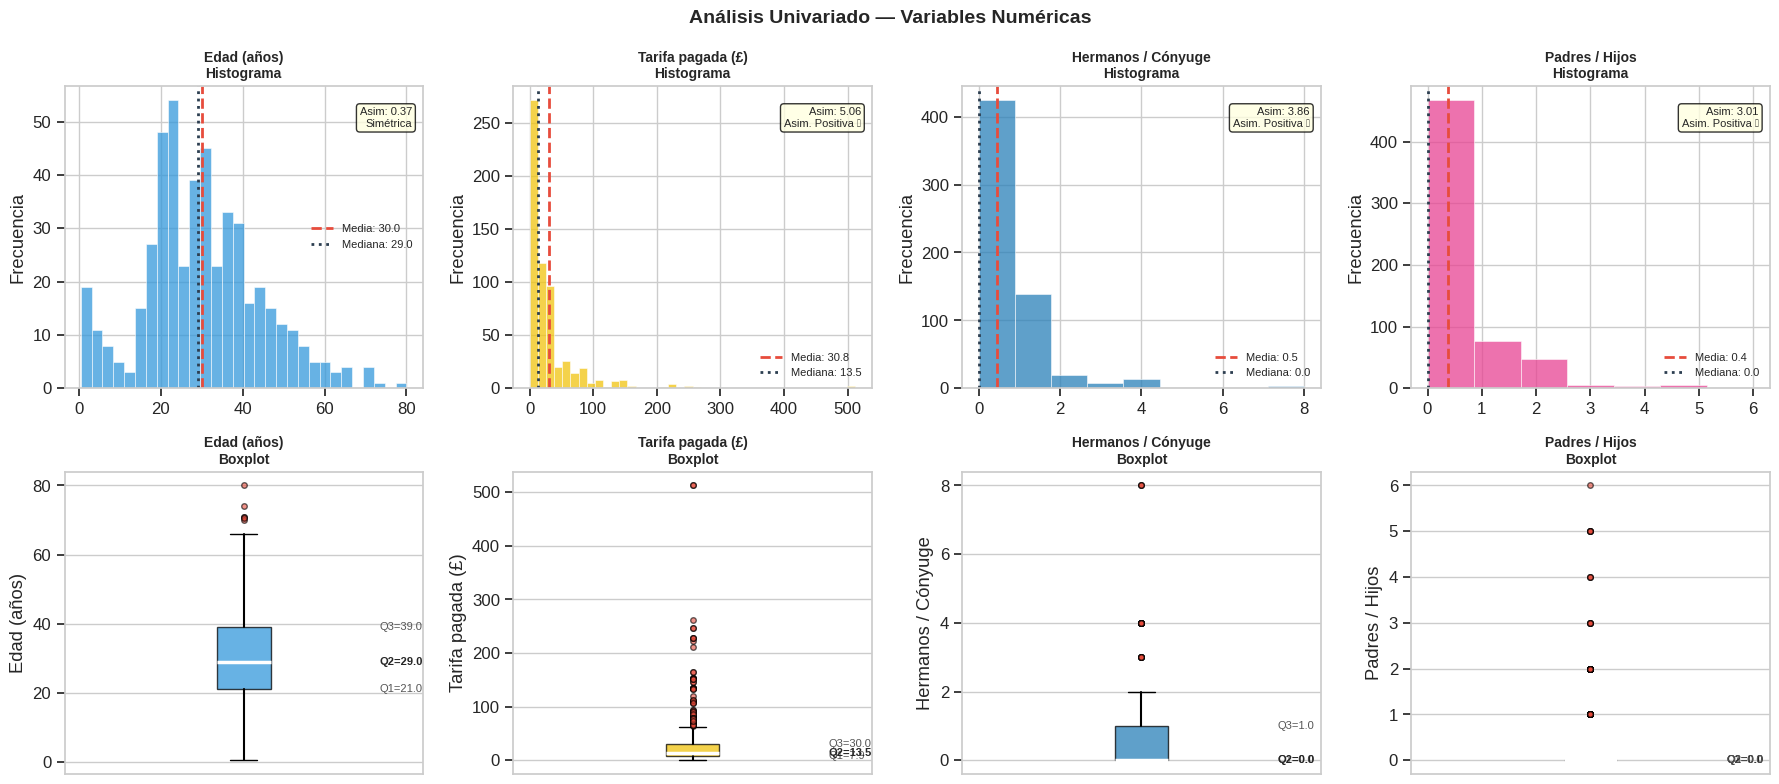

📌 INTERPRETACIONES:

🔹 AGE (Edad):
   Media=30.0 | Mediana=29.0 | Nulos=117
   Distribución aproximadamente normal con leve asimetría positiva.

🔹 FARE (Tarifa):
   Media=£30.78 | Mediana=£13.50 | Máx=£512.33
   Alta asimetría positiva. La mediana es más representativa que la media.

🔹 SIBSP / PARCH:
   Moda SibSp=0 | Moda Parch=0
   La mayoría viajaba sin familiares directos a bordo.


In [12]:
# ============================================================
# 1.6 — VISUALIZACIÓN: HISTOGRAMAS + BOXPLOTS
# ============================================================

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Análisis Univariado — Variables Numéricas',
             fontsize=14, fontweight='bold')

info_vars = [
    ('Age',   'Edad (años)',         COLORES['neutro'],        30),
    ('Fare',  'Tarifa pagada (£)',   COLORES['primera_clase'], 40),
    ('SibSp', 'Hermanos / Cónyuge',  COLORES['masculino'],     9),
    ('Parch', 'Padres / Hijos',      COLORES['femenino'],      7),
]

for col_idx, (var, etiqueta, color, bins) in enumerate(info_vars):
    datos = train[var].dropna()

    # ── Fila 0: Histograma ───────────────────────────────────
    ax_hist = axes[0, col_idx]
    ax_hist.hist(datos, bins=bins, color=color, alpha=0.75,
                 edgecolor='white', linewidth=0.5)
    ax_hist.axvline(datos.mean(), color='#e74c3c', linestyle='--',
                    linewidth=2, label=f'Media: {datos.mean():.1f}')
    ax_hist.axvline(datos.median(), color='#2c3e50', linestyle=':',
                    linewidth=2, label=f'Mediana: {datos.median():.1f}')
    ax_hist.set_title(f'{etiqueta}\nHistograma', fontsize=10, fontweight='bold')
    ax_hist.set_ylabel('Frecuencia')
    ax_hist.legend(fontsize=8)

    skew = datos.skew()
    if abs(skew) < 0.5:
        tipo = "Simétrica"
    elif skew > 0:
        tipo = "Asim. Positiva ↗"
    else:
        tipo = "Asim. Negativa ↙"

    ax_hist.text(0.97, 0.93, f'Asim: {skew:.2f}\n{tipo}',
                 transform=ax_hist.transAxes, ha='right', va='top',
                 fontsize=8,
                 bbox=dict(boxstyle='round,pad=0.3',
                           facecolor='lightyellow', alpha=0.8))

    # ── Fila 1: Boxplot ──────────────────────────────────────
    ax_box = axes[1, col_idx]
    bp = ax_box.boxplot(datos, vert=True, patch_artist=True,
                        medianprops=dict(color='white', linewidth=2.5),
                        whiskerprops=dict(linewidth=1.5),
                        flierprops=dict(marker='o',
                                        markerfacecolor='#e74c3c',
                                        markersize=4, alpha=0.6))
    bp['boxes'][0].set_facecolor(color)
    bp['boxes'][0].set_alpha(0.75)
    ax_box.set_title(f'{etiqueta}\nBoxplot', fontsize=10, fontweight='bold')
    ax_box.set_ylabel(etiqueta)
    ax_box.set_xticks([])

    q1  = datos.quantile(0.25)
    med = datos.quantile(0.50)
    q3  = datos.quantile(0.75)
    ax_box.text(1.38, q1,  f'Q1={q1:.1f}',  fontsize=8, va='center', color='#555')
    ax_box.text(1.38, med, f'Q2={med:.1f}', fontsize=8, va='center', fontweight='bold')
    ax_box.text(1.38, q3,  f'Q3={q3:.1f}',  fontsize=8, va='center', color='#555')

plt.tight_layout()
plt.show()

print("📌 INTERPRETACIONES:")
print()
print("🔹 AGE (Edad):")
print(f"   Media={train['Age'].mean():.1f} | Mediana={train['Age'].median():.1f} | "
      f"Nulos={train['Age'].isnull().sum()}")
print("   Distribución aproximadamente normal con leve asimetría positiva.")

print()
print("🔹 FARE (Tarifa):")
print(f"   Media=£{train['Fare'].mean():.2f} | Mediana=£{train['Fare'].median():.2f} | "
      f"Máx=£{train['Fare'].max():.2f}")
print("   Alta asimetría positiva. La mediana es más representativa que la media.")

print()
print("🔹 SIBSP / PARCH:")
print(f"   Moda SibSp={train['SibSp'].mode()[0]} | Moda Parch={train['Parch'].mode()[0]}")
print("   La mayoría viajaba sin familiares directos a bordo.")

---
## 1.7 — Análisis Univariado: Variables Categóricas

Para variables categóricas usamos **frecuencias y proporciones**.
No tiene sentido calcular una "media de género" o una "desviación estándar de puertos".

Lo que nos interesa es:
- ¿Qué categorías existen?
- ¿Cuántos pasajeros hay en cada categoría?
- ¿Hay categorías dominantes que puedan sesgar el modelo?

In [13]:
# ============================================================
# 1.7 — ANÁLISIS UNIVARIADO: VARIABLES CATEGÓRICAS
# ============================================================

vars_cat = {
    'Pclass'   : ('Clase Social',       {1:'Primera', 2:'Segunda', 3:'Tercera'}),
    'Sex'      : ('Género',             {'male':'Masculino', 'female':'Femenino'}),
    'Embarked' : ('Puerto de Embarque', {'S':'Southampton','C':'Cherburgo','Q':'Queenstown'}),
}

print("=" * 70)
print("TABLAS DE FRECUENCIA — VARIABLES CATEGÓRICAS")
print("=" * 70)

for var, (nombre, etiquetas) in vars_cat.items():
    print(f"\n📊 {nombre} ({var}):")
    freq = train[var].value_counts()
    pct  = train[var].value_counts(normalize=True) * 100
    tabla = pd.DataFrame({
        'Frecuencia'     : freq,
        'Porcentaje (%)' : pct.round(2)
    })
    tabla.index = [etiquetas.get(i, i) for i in tabla.index]
    display(tabla)

TABLAS DE FRECUENCIA — VARIABLES CATEGÓRICAS

📊 Clase Social (Pclass):


,Frecuencia,Porcentaje (%)
Tercera,338,55.8700
Primera,143,23.6400
Segunda,124,20.5000



📊 Género (Sex):


,Frecuencia,Porcentaje (%)
Masculino,392,64.7900
Femenino,213,35.2100



📊 Puerto de Embarque (Embarked):


,Frecuencia,Porcentaje (%)
Southampton,431,71.4800
Cherburgo,120,19.9000
Queenstown,52,8.6200


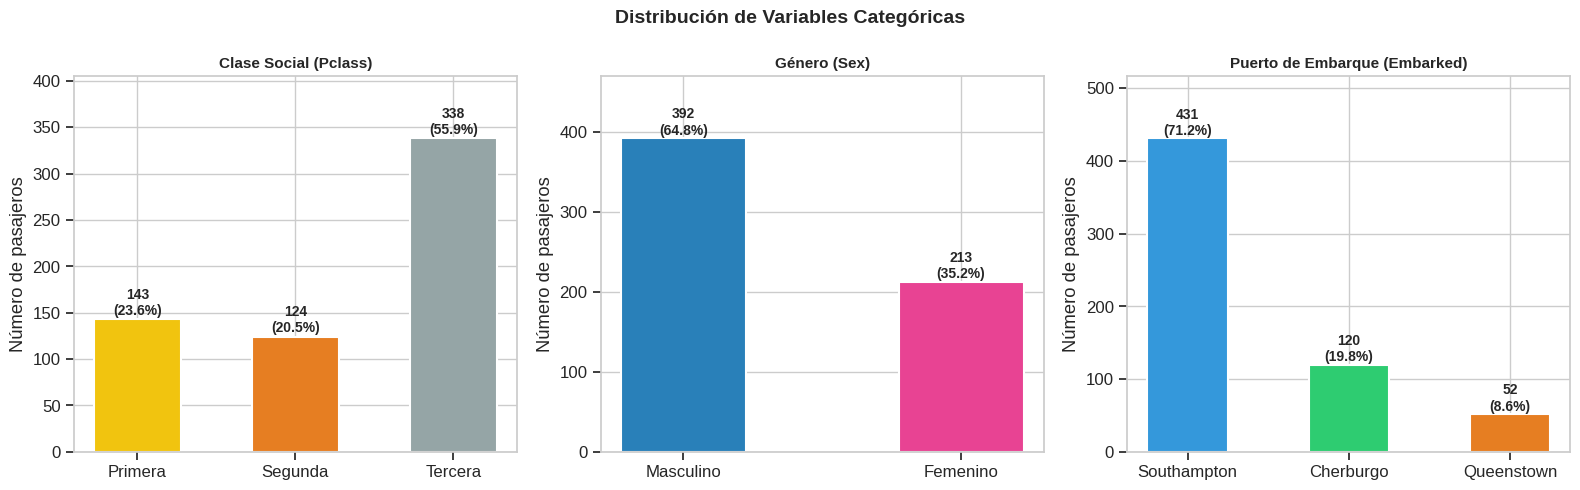

📌 OBSERVACIONES:
   • Tercera clase es la más grande (55%) — el Titanic también era barco de emigrantes
   • 65% de pasajeros eran hombres, 35% mujeres
   • 72% embarcó en Southampton — el puerto principal de salida


In [14]:
# ============================================================
# 1.7 — VISUALIZACIÓN: VARIABLES CATEGÓRICAS
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribución de Variables Categóricas',
             fontsize=14, fontweight='bold')

# ── Clase Social ─────────────────────────────────────────────
conteo_clase = train['Pclass'].value_counts().sort_index()
axes[0].bar(['Primera', 'Segunda', 'Tercera'],
            conteo_clase.values,
            color=[COLORES['primera_clase'],
                   COLORES['segunda_clase'],
                   COLORES['tercera_clase']],
            edgecolor='white', linewidth=1.5, width=0.55)
axes[0].set_title('Clase Social (Pclass)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Número de pasajeros')
axes[0].set_ylim(0, max(conteo_clase) * 1.2)
for i, v in enumerate(conteo_clase.values):
    axes[0].text(i, v + 5, f'{v}\n({v/len(train)*100:.1f}%)',
                ha='center', fontweight='bold', fontsize=10)

# ── Género ───────────────────────────────────────────────────
conteo_sex = train['Sex'].value_counts()
axes[1].bar(['Masculino', 'Femenino'],
            [conteo_sex['male'], conteo_sex['female']],
            color=[COLORES['masculino'], COLORES['femenino']],
            edgecolor='white', linewidth=1.5, width=0.45)
axes[1].set_title('Género (Sex)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Número de pasajeros')
axes[1].set_ylim(0, max(conteo_sex) * 1.2)
for i, (k, v) in enumerate(zip(['male','female'],
                                 [conteo_sex['male'], conteo_sex['female']])):
    axes[1].text(i, v + 5, f'{v}\n({v/len(train)*100:.1f}%)',
                ha='center', fontweight='bold', fontsize=10)

# ── Puerto de Embarque ───────────────────────────────────────
conteo_emb = train['Embarked'].value_counts()
port_map    = {'S': 'Southampton', 'C': 'Cherburgo', 'Q': 'Queenstown'}
port_colors = [COLORES['neutro'], COLORES['sobrevivio'], COLORES['segunda_clase']]
axes[2].bar([port_map[k] for k in conteo_emb.index],
            conteo_emb.values,
            color=port_colors, edgecolor='white', linewidth=1.5, width=0.5)
axes[2].set_title('Puerto de Embarque (Embarked)', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Número de pasajeros')
axes[2].set_ylim(0, max(conteo_emb) * 1.2)
for i, v in enumerate(conteo_emb.values):
    axes[2].text(i, v + 5, f'{v}\n({v/len(train)*100:.1f}%)',
                ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

print("📌 OBSERVACIONES:")
print("   • Tercera clase es la más grande (55%) — el Titanic también era barco de emigrantes")
print("   • 65% de pasajeros eran hombres, 35% mujeres")
print("   • 72% embarcó en Southampton — el puerto principal de salida")

---
## 1.8 — Análisis Bivariado: Relación con `Survived`

El análisis **bivariado** estudia la relación entre dos variables.
Aquí comparamos cada variable con `Survived` para identificar
cuáles tienen **mayor poder predictivo**.

> 💡 Una variable es "buena predictora" si sus valores difieren
> notablemente entre los que sobrevivieron y los que no.

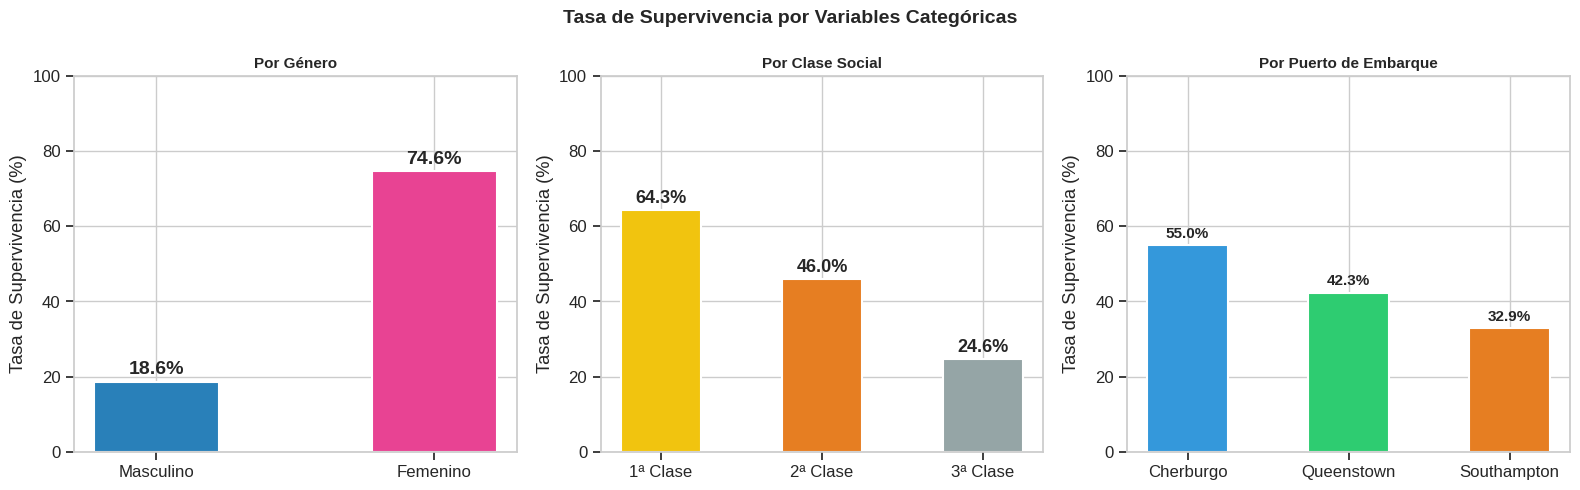

In [15]:
# ============================================================
# 1.8 — ANÁLISIS BIVARIADO: VARIABLES CATEGÓRICAS vs SURVIVED
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Tasa de Supervivencia por Variables Categóricas',
             fontsize=14, fontweight='bold')

# ── Género ───────────────────────────────────────────────────
surv_sex = train.groupby('Sex')['Survived'].mean() * 100
axes[0].bar(['Masculino', 'Femenino'],
            [surv_sex['male'], surv_sex['female']],
            color=[COLORES['masculino'], COLORES['femenino']],
            edgecolor='white', linewidth=1.5, width=0.45)
axes[0].set_title('Por Género', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Tasa de Supervivencia (%)')
axes[0].set_ylim(0, 100)
for i, val in enumerate([surv_sex['male'], surv_sex['female']]):
    axes[0].text(i, val + 2, f'{val:.1f}%',
                ha='center', fontweight='bold', fontsize=14)

# ── Clase Social ─────────────────────────────────────────────
surv_class = train.groupby('Pclass')['Survived'].mean() * 100
axes[1].bar(['1ª Clase', '2ª Clase', '3ª Clase'],
            surv_class.values,
            color=[COLORES['primera_clase'],
                   COLORES['segunda_clase'],
                   COLORES['tercera_clase']],
            edgecolor='white', linewidth=1.5, width=0.5)
axes[1].set_title('Por Clase Social', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Tasa de Supervivencia (%)')
axes[1].set_ylim(0, 100)
for i, val in enumerate(surv_class.values):
    axes[1].text(i, val + 2, f'{val:.1f}%',
                ha='center', fontweight='bold', fontsize=13)

# ── Puerto de Embarque ───────────────────────────────────────
surv_emb = train.groupby('Embarked')['Survived'].mean() * 100
axes[2].bar(['Cherburgo', 'Queenstown', 'Southampton'],
            [surv_emb.get('C', 0), surv_emb.get('Q', 0), surv_emb.get('S', 0)],
            color=[COLORES['neutro'], COLORES['sobrevivio'], COLORES['segunda_clase']],
            edgecolor='white', linewidth=1.5, width=0.5)
axes[2].set_title('Por Puerto de Embarque', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Tasa de Supervivencia (%)')
axes[2].set_ylim(0, 100)
for i, val in enumerate([surv_emb.get('C',0), surv_emb.get('Q',0), surv_emb.get('S',0)]):
    axes[2].text(i, val + 2, f'{val:.1f}%',
                ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

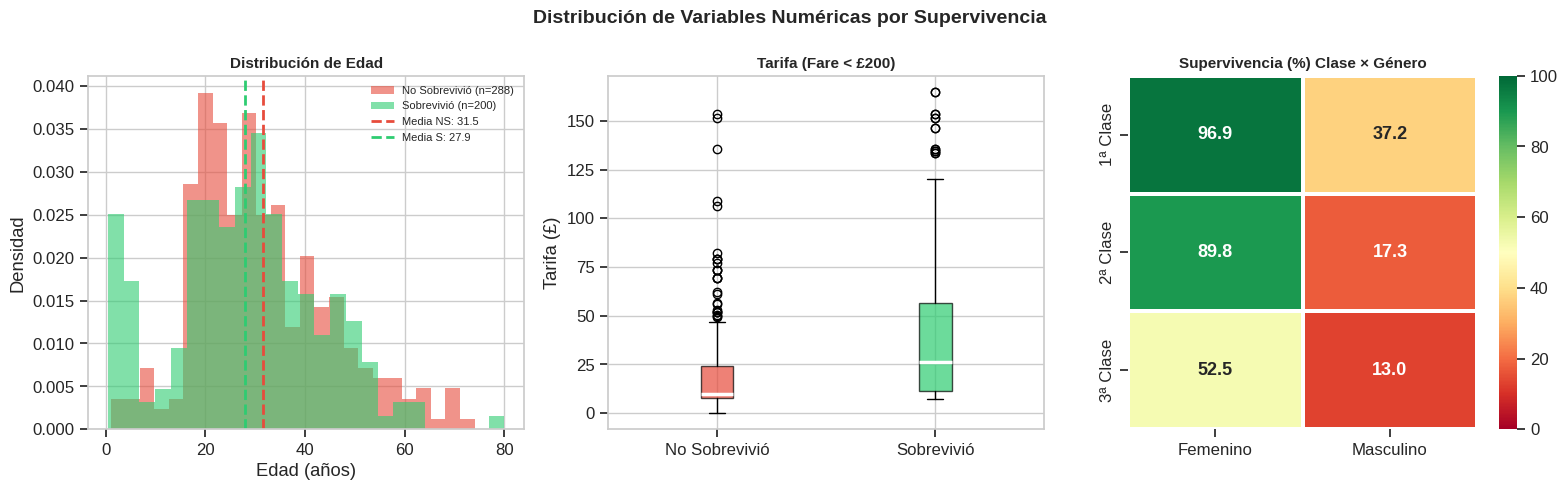

📌 HALLAZGOS CLAVE del análisis bivariado:

   🔵 GÉNERO   → Mujeres: 74.6% vs Hombres: 18.6%
                Las mujeres tenían 4.0x más probabilidad de sobrevivir

   🟡 CLASE 1  → Tasa de supervivencia: 64.3%
   🟡 CLASE 2  → Tasa de supervivencia: 46.0%
   🟡 CLASE 3  → Tasa de supervivencia: 24.6%

   🟠 TARIFA   → Los sobrevivientes pagaron tarifas significativamente más altas
                (proxy directo de clase social y acceso a botes)


In [17]:
# ============================================================
# 1.8 — ANÁLISIS BIVARIADO: VARIABLES NUMÉRICAS vs SURVIVED
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribución de Variables Numéricas por Supervivencia',
             fontsize=14, fontweight='bold')

# ── Edad ─────────────────────────────────────────────────────
edad_s  = train.loc[train['Survived']==1, 'Age'].dropna()
edad_ns = train.loc[train['Survived']==0, 'Age'].dropna()
axes[0].hist(edad_ns, bins=25, alpha=0.6,
             color=COLORES['no_sobrevivio'],
             label=f'No Sobrevivió (n={len(edad_ns)})', density=True)
axes[0].hist(edad_s, bins=25, alpha=0.6,
             color=COLORES['sobrevivio'],
             label=f'Sobrevivió (n={len(edad_s)})', density=True)
axes[0].axvline(edad_ns.mean(), color=COLORES['no_sobrevivio'],
                linestyle='--', linewidth=2,
                label=f'Media NS: {edad_ns.mean():.1f}')
axes[0].axvline(edad_s.mean(), color=COLORES['sobrevivio'],
                linestyle='--', linewidth=2,
                label=f'Media S: {edad_s.mean():.1f}')
axes[0].set_title('Distribución de Edad', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Edad (años)')
axes[0].set_ylabel('Densidad')
axes[0].legend(fontsize=8)

# ── Tarifa ───────────────────────────────────────────────────
fare_s  = train.loc[train['Survived']==1, 'Fare']
fare_ns = train.loc[train['Survived']==0, 'Fare']
fare_plot = train[train['Fare'] < 200]
bp = axes[1].boxplot(
    [fare_plot.loc[fare_plot['Survived']==0, 'Fare'],
     fare_plot.loc[fare_plot['Survived']==1, 'Fare']],
    labels=['No Sobrevivió', 'Sobrevivió'],
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2.5)
)
bp['boxes'][0].set_facecolor(COLORES['no_sobrevivio'])
bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor(COLORES['sobrevivio'])
bp['boxes'][1].set_alpha(0.7)
axes[1].set_title('Tarifa (Fare < £200)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Tarifa (£)')

# ── Heatmap Clase × Género ───────────────────────────────────
pivot = train.pivot_table(
    values='Survived', index='Pclass',
    columns='Sex', aggfunc='mean') * 100
pivot.index   = ['1ª Clase', '2ª Clase', '3ª Clase']
pivot.columns = ['Femenino', 'Masculino']
sns.heatmap(pivot, ax=axes[2],
            annot=True, fmt='.1f',
            cmap='RdYlGn', vmin=0, vmax=100,
            linewidths=1.5, linecolor='white',
            annot_kws={'size': 13, 'weight': 'bold'})
axes[2].set_title('Supervivencia (%) Clase × Género',
                  fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("📌 HALLAZGOS CLAVE del análisis bivariado:")
print()
surv_f = train[train['Sex']=='female']['Survived'].mean()*100
surv_m = train[train['Sex']=='male']['Survived'].mean()*100
print(f"   🔵 GÉNERO   → Mujeres: {surv_f:.1f}% vs Hombres: {surv_m:.1f}%")
print(f"                Las mujeres tenían {surv_f/surv_m:.1f}x más probabilidad de sobrevivir")
print()
for c in [1, 2, 3]:
    t = train[train['Pclass']==c]['Survived'].mean()*100
    print(f"   🟡 CLASE {c}  → Tasa de supervivencia: {t:.1f}%")
print()
print("   🟠 TARIFA   → Los sobrevivientes pagaron tarifas significativamente más altas")
print("                (proxy directo de clase social y acceso a botes)")

---
## 1.9 — Detección de Outliers

### ¿Qué es un outlier?

Un **outlier** (valor atípico) es una observación que se aleja significativamente
del resto de los datos. Pueden ser:

- **Errores de medición** → se deben corregir o eliminar
- **Valores reales extremos** → deben mantenerse (ej: un millonario que pagó £512)

### Método del IQR (Rango Intercuartílico):

$$\text{Límite inferior} = Q1 - 1.5 \times IQR$$
$$\text{Límite superior} = Q3 + 1.5 \times IQR$$

Todo valor fuera de ese rango se considera un outlier.

In [18]:
# ============================================================
# 1.9 — DETECCIÓN DE OUTLIERS
# ============================================================

print("=" * 70)
print("DETECCIÓN DE OUTLIERS — MÉTODO IQR")
print("=" * 70)

vars_outlier = ['Age', 'Fare', 'SibSp', 'Parch']

for var in vars_outlier:
    datos = train[var].dropna()
    Q1  = datos.quantile(0.25)
    Q3  = datos.quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    outliers = datos[(datos < lim_inf) | (datos > lim_sup)]

    print(f"\n🔹 {var}:")
    print(f"   Q1={Q1:.2f} | Q3={Q3:.2f} | IQR={IQR:.2f}")
    print(f"   Límites: [{lim_inf:.2f}, {lim_sup:.2f}]")
    print(f"   Outliers detectados: {len(outliers)} "
          f"({len(outliers)/len(datos)*100:.1f}%)")
    if len(outliers) > 0:
        print(f"   Valores extremos: {sorted(outliers.unique())[-5:]}")

DETECCIÓN DE OUTLIERS — MÉTODO IQR

🔹 Age:
   Q1=21.00 | Q3=39.00 | IQR=18.00
   Límites: [-6.00, 66.00]
   Outliers detectados: 6 (1.2%)
   Valores extremos: [np.float64(70.0), np.float64(70.5), np.float64(71.0), np.float64(74.0), np.float64(80.0)]

🔹 Fare:
   Q1=7.90 | Q3=30.00 | IQR=22.10
   Límites: [-25.26, 63.16]
   Outliers detectados: 75 (12.4%)
   Valores extremos: [np.float64(221.7792), np.float64(227.525), np.float64(247.5208), np.float64(262.375), np.float64(512.3292)]

🔹 SibSp:
   Q1=0.00 | Q3=1.00 | IQR=1.00
   Límites: [-1.50, 2.50]
   Outliers detectados: 23 (3.8%)
   Valores extremos: [np.int64(3), np.int64(4), np.int64(8)]

🔹 Parch:
   Q1=0.00 | Q3=0.00 | IQR=0.00
   Límites: [0.00, 0.00]
   Outliers detectados: 138 (22.8%)
   Valores extremos: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


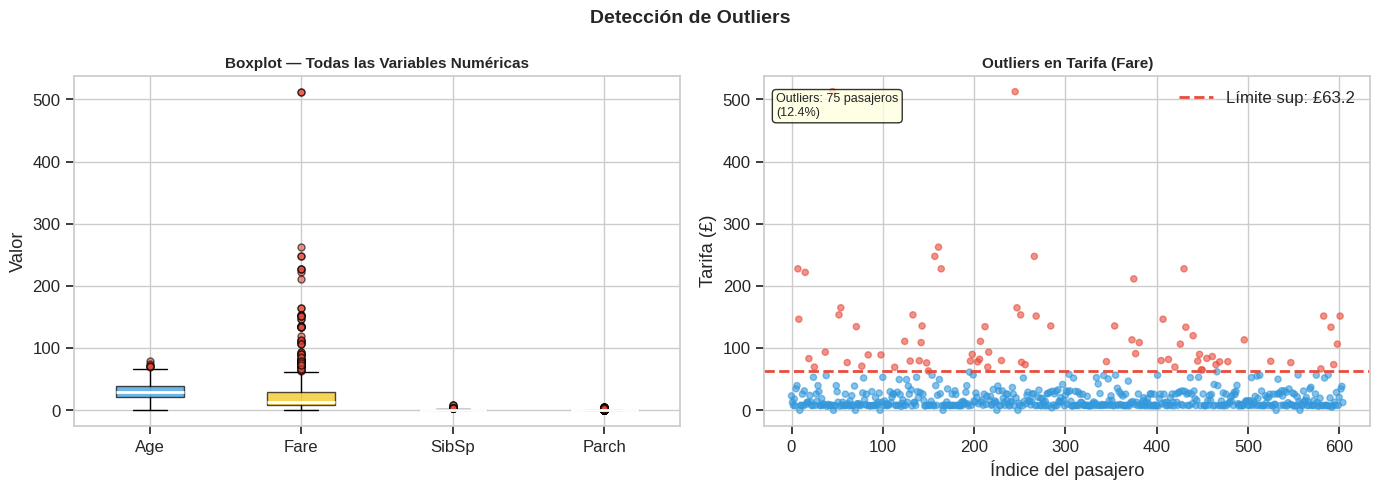

📌 DECISIÓN sobre outliers en Fare:
   Los 75 pasajeros con tarifa > £63 son
   pasajeros REALES de primera clase con camarotes privados.
   No los eliminamos — son datos válidos y muy informativos.
   En Sección 5 aplicaremos transformación logarítmica si es necesario.


In [19]:
# ============================================================
# 1.9 — VISUALIZACIÓN DE OUTLIERS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Detección de Outliers', fontsize=14, fontweight='bold')

# ── Boxplot comparativo ──────────────────────────────────────
data_box = [train[v].dropna().values for v in ['Age', 'Fare', 'SibSp', 'Parch']]
bp = axes[0].boxplot(data_box,
                     labels=['Age', 'Fare', 'SibSp', 'Parch'],
                     patch_artist=True,
                     medianprops=dict(color='white', linewidth=2),
                     flierprops=dict(marker='o', markerfacecolor='#e74c3c',
                                     markersize=5, alpha=0.6))
colores_box = [COLORES['neutro'], COLORES['primera_clase'],
               COLORES['masculino'], COLORES['femenino']]
for patch, color in zip(bp['boxes'], colores_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_title('Boxplot — Todas las Variables Numéricas',
                  fontsize=11, fontweight='bold')
axes[0].set_ylabel('Valor')

# ── Scatter: Fare con umbral ─────────────────────────────────
Q1_fare  = train['Fare'].quantile(0.25)
Q3_fare  = train['Fare'].quantile(0.75)
IQR_fare = Q3_fare - Q1_fare
lim_fare = Q3_fare + 1.5 * IQR_fare

colores_scatter = [COLORES['no_sobrevivio'] if f > lim_fare
                   else COLORES['neutro']
                   for f in train['Fare']]
axes[1].scatter(train.index, train['Fare'],
                c=colores_scatter, alpha=0.6, s=20)
axes[1].axhline(y=lim_fare, color='#e74c3c', linestyle='--',
                linewidth=2, label=f'Límite sup: £{lim_fare:.1f}')
axes[1].set_title('Outliers en Tarifa (Fare)',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Índice del pasajero')
axes[1].set_ylabel('Tarifa (£)')
axes[1].legend()

n_outliers_fare = (train['Fare'] > lim_fare).sum()
axes[1].text(0.02, 0.95,
             f'Outliers: {n_outliers_fare} pasajeros\n'
             f'({n_outliers_fare/len(train)*100:.1f}%)',
             transform=axes[1].transAxes, va='top',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8),
             fontsize=9)

plt.tight_layout()
plt.show()

print("📌 DECISIÓN sobre outliers en Fare:")
print(f"   Los {n_outliers_fare} pasajeros con tarifa > £{lim_fare:.0f} son")
print("   pasajeros REALES de primera clase con camarotes privados.")
print("   No los eliminamos — son datos válidos y muy informativos.")
print("   En Sección 5 aplicaremos transformación logarítmica si es necesario.")

---
## 1.10 — Resumen y Conclusiones del EDA

### ¿Qué aprendimos en esta sección?

In [20]:
# ============================================================
# 1.10 — RESUMEN EJECUTIVO DEL EDA
# ============================================================

print("=" * 70)
print("       RESUMEN EJECUTIVO — ANÁLISIS EXPLORATORIO")
print("=" * 70)

surv_f  = train[train['Sex']=='female']['Survived'].mean()*100
surv_m  = train[train['Sex']=='male']['Survived'].mean()*100
surv_1  = train[train['Pclass']==1]['Survived'].mean()*100
surv_3  = train[train['Pclass']==3]['Survived'].mean()*100
pct_nul_age   = train['Age'].isnull().mean()*100
pct_nul_cabin = train['Cabin'].isnull().mean()*100

print(f"""
  📐 DATASET
     • {train.shape[0]} pasajeros × {train.shape[1]} variables
     • {porcentaje[1]:.1f}% sobrevivió — dataset desbalanceado

  🔴 VALORES NULOS A TRATAR
     • Age:    {pct_nul_age:.1f}% → imputar con mediana por grupo
     • Cabin:  {pct_nul_cabin:.1f}% → crear indicador HasCabin
     • Embarked: 2 filas → imputar con moda

  🏆 VARIABLES MÁS PROMETEDORAS (por poder predictivo)
     1. Sex      → Mujeres {surv_f:.0f}% vs Hombres {surv_m:.0f}% supervivencia
     2. Pclass   → 1ª clase {surv_1:.0f}% vs 3ª clase {surv_3:.0f}% supervivencia
     3. Fare     → Alta tarifa correlaciona con supervivencia
     4. Age      → Los niños tuvieron prioridad en la evacuación
     5. Embarked → Pasajeros de Cherburgo sobrevivieron más (eran más ricos)

  💡 VARIABLES A CREAR (Sección 5)
     • Title     → Extraer del nombre (Mr., Mrs., Master., Miss.)
     • FamilySize → SibSp + Parch + 1
     • IsAlone   → Viaja solo (FamilySize == 1)
     • HasCabin  → Tiene camarote registrado

  ⚠️  OUTLIERS
     • Fare: valores > £{Q3_fare + 1.5*IQR_fare:.0f} son pasajeros reales de 1ª clase
     • Se mantienen — son datos válidos e informativos
""")

print("=" * 70)
print("  ✅ EDA completado. Continuamos con Sección 2 — Estadística Descriptiva.")
print("=" * 70)

       RESUMEN EJECUTIVO — ANÁLISIS EXPLORATORIO

  📐 DATASET
     • 605 pasajeros × 12 variables
     • 38.3% sobrevivió — dataset desbalanceado

  🔴 VALORES NULOS A TRATAR
     • Age:    19.3% → imputar con mediana por grupo
     • Cabin:  78.5% → crear indicador HasCabin
     • Embarked: 2 filas → imputar con moda

  🏆 VARIABLES MÁS PROMETEDORAS (por poder predictivo)
     1. Sex      → Mujeres 75% vs Hombres 19% supervivencia
     2. Pclass   → 1ª clase 64% vs 3ª clase 25% supervivencia
     3. Fare     → Alta tarifa correlaciona con supervivencia
     4. Age      → Los niños tuvieron prioridad en la evacuación
     5. Embarked → Pasajeros de Cherburgo sobrevivieron más (eran más ricos)

  💡 VARIABLES A CREAR (Sección 5)
     • Title     → Extraer del nombre (Mr., Mrs., Master., Miss.)
     • FamilySize → SibSp + Parch + 1
     • IsAlone   → Viaja solo (FamilySize == 1)
     • HasCabin  → Tiene camarote registrado

  ⚠️  OUTLIERS
     • Fare: valores > £63 son pasajeros reales de 1

---
## 🏁 Resumen de la Sección 1

| Paso | Hallazgo principal |
|------|--------------------|
| Carga | 891 pasajeros de entrenamiento, 418 de prueba |
| Tipos | 5 numéricas, 7 de texto/categóricas |
| Nulos | 3 variables afectadas: Age (20%), Cabin (77%), Embarked (<1%) |
| Objetivo | 61.6% no sobrevivió vs 38.4% sobrevivió — desbalanceado |
| Mejor predictor | Género: mujeres ~74% vs hombres ~19% |
| Clase social | 1ª clase ~63% vs 3ª clase ~24% supervivencia |

---

## ➡️ Siguiente: Sección 2 — Estadística Descriptiva

En la próxima sección calcularemos e interpretaremos en profundidad:
media, mediana, moda, desviación estándar, percentiles, asimetría y curtosis,
con énfasis en qué significa cada medida en el contexto del Titanic.